---
title: Demonstration of pyOrchestra: Analysis of data from Lorah & Herman (1988)
subtitle: Travertine depositing stream
author:
  - name: Timo Heimovaara
    affiliations: Delft University of Technology, department of Geoscience & Engineering
    orcid:
    email: t.j.heimovaara@tudelft.nl
license: CC-BY-NC-ND-4.0 (https://creativecommons.org/licenses/by-nc-nd/4.0/).
date: 2026-01-30
kernelspec:
    name: python3
    display_name: 'Python 3.13'
---

In [1]:
# Import libraries required for running all simulations
import locale
# locale.setlocale(locale.LC_ALL, 'en_US.UTF-8') # for formatting numbers with commas
locale.setlocale(locale.LC_ALL, 'C') # 

import os
import sys
from IPython.utils import capture
from IPython.display import display, Markdown
from pathlib import Path
from contextlib import chdir

import numpy as np
import matplotlib.pyplot as plt
import PyORCHESTRA # here, the ORCHESTRA submodule is imported
import pandas as pd
import seaborn as sns

%matplotlib widget
sns.set()

# Prepare a file to capture PyOrchestra output
capture_file = open("pyorchestra_output.log", "w")


# pyOrchestra is implemented in C++
# Save original stdout file descriptor
# original_stdout_fd = sys.stdout.fileno()

# Duplicate original stdout so we can restore it later
# saved_stdout_fd = os.dup(original_stdout_fd)



# We need to import some Orchestra files. We need to know the path layout on 
# the local machine:
def find_book_root(start: Path | None = None) -> Path:
    """
    Walk upward from `start` (or CWD) until a directory containing Jupyter Book
    marker files is found. Returns the path to the book root.
    Raises FileNotFoundError if no root is found.
    """
    config_any = {"_config.yml", "_config.yaml"}      # some projectrs use .yaml
    myst_any = {"myst.yml", "myst.yaml"}            # jupyter-book uses _toc.yml

    cur = Path(Path.cwd()).resolve()

    for parent in [cur, *cur.parents]:
        children = {f.name for f in parent.iterdir()} if parent.exists() else set()
        has_any_config = bool(config_any & children)
        has_any_myst = bool(myst_any & children)
        if has_any_config and has_any_myst:
            return parent

    raise FileNotFoundError(
        f"Could not find Jupyter Book root (no _config.y* and myst.y* found above {cur})"
    )


def path_from_book_root(*parts: str | Path) -> Path:
    root = find_book_root()
    p = (root.joinpath(*parts)).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Path not found: {p}")
    return p

# In order for orchestra to run we need to change directory to the directory with the input file:


# Example usage:
# input_file = path_from_book_root("content", "week 02", "Orchestra_simulation", "chemistry1.inp")
# print("Input file:", input_file)

orchestra_path = path_from_book_root("content", "project_THe", "Travertine_Example_Tutorial","Travertine_Orchestra")
# print(orchestra_path)

## Unravelling the geochemistry of Travertine deposition along a stream
The data for this exercise are taken from:
**Reference:** Lorah, M.M. & Herman J.S. (1988) – *The chemical evolution of a travertine-depositing stream: Geochemical processes and mass transfer reactions*  
<https://doi-org.tudelft.idm.oclc.org/10.1029/WR024i009p01541>  

In the paper by Lorah and Herman (1988) you will see that several sampling trips were made to collect samples along a stream moving away from the hotsprings where the stream originates, past a waterfall and then further down stream. In Table 1, analysis results are presented for to sampling campaigns, one on 14 October 1984 and another on 6  April 1985. We will use these data for our analysis.

The aim of the analysis is to increase our understanding of the formation of travertine deposits along the stream and especially near the water fall.

The analysis you will do follows the approach given in the paper and consists in principle of two main steps:
1. We use that analysis results from the table to assess the the most likely in-situ conditions at the moment of sampling. The analysis results, give totals of the elements expressed as shown in the header of the table. The true speciation will vary, elements will be present in other forms as well, solid minerals may control the composition of the water, but are not sampled with the water. The system may, or may not be in equilibrium. We analyse this problem with Orchestra using an Chemistry input file where we give the total of all measured compounds as master species, and we do not allow any minerals to precipitate, but we do report the SI-values for those minerals.
2. After doing the first analysis, we have quite alot of additional information compared to the chemical analysis results from the lab, we know partial $\text{CO}_2[g]$ pressure and the SI-values for possible minerals for the water samples along the river. It is safe to assume that water down stream from the spring originated from the spring and that its composition should be realated to the water at the spring. With this assumption we can use Orchestra to simulate changes related to the measurements obtained above. For example: if we have water from S-1 and move this to the conditions at D-3 ($\text{CO}_2[g]$ pressure and Calcite-SI), how much calcite would have precipitated in between?

In Orchestra you define the type of calculation you want to do with a *chemistry.inp* file. For this assignment we need two types:
1. To calculate the equilibrium calculations for our system without allowing minerals to precipitate;
2. As similar input file, but where we allow the minerals to precipitate. As we want to compare samples along the line, we also need to be able to control the SI-value which is used to achieve the equilibrium. Normally, the SI-value is assumed to be zero for supersaturated samples, in this assignment we need to allow the model to equilibrate assuming higher, or even lower SI-values. In addition, the $\text{CO}_2[g]$ pressure needs to be fixed as well, which we can achieve by fixing the CO2[g].logact.



```{exercise} **Assumptions**
As stated above, we assume that the composition of the water downstream of the spring is closely related to the composition of the water at the stream. Please carefully evaluate this assumption and try to find reasons why this assumption might not be true? What can you do to mitigate the reasons you found?
```

## Step 1: Assessing the water samples
For this first step I have already prepared an Orchestra input file using the *orchestra2026.jar* Graphical User Interface (GUI). Please have a look at this file with the GUI. 
The approach was quite simple, I have added all the analysed compounds that are found in the table as primary entities in the dissolved phase (*diss*). We define the pH as a fixed logact and we assume that water is the solute phase with a fixed logactivity of 0. We do not select any minerals on the *Phases & Reactions* tab, because we do not allow for any precipitation. We assume that the water samples are stored in bottles with out any gas-phase (head space), we set the gasvolume to be zero on the *Variables* tab. This chemical system is defined in *chemistry1.inp*.

In order to illustrate the steps, we will analyse two water samples: S1 and F1. Please note that the concentrations are given in $\text{mg/l}$ and the temperature in $^\text{o}\text{C}$, we need to traslate these numbers to $\text{mol/l}$ and $\text{K}$ in order to work with Orchestra.

```{hint} Creating the *chemistry.inp* file
Using the Orchestra GUI shown in [](#master_species)  we are able to define a system of the primary entities. You do this by selecting the **Chemistry** tab on the right in the ORCHESTRA-COMPOSER window. The **Chemistry** tab shows a number of tabs which fill the *chemistry1.inp* file. We start by selecting tab **Primary entities/ Master Species**. Remember that we select the Master Species in such a way that we can create all other species for our problem. In addition we need to use these species to define the total moles of each master species present in the system (including the amounts of these master species present in the secondary species).
```


## Initialise the problem 
In order solve this problem with pyOrchestra we first initialize our problem using the *chemistry_Travertine.inp* file. 
This file predefines the aqueous chemical system in such a way that we can use the information from the tables in the paper as inputs to the Orchestra simulation.

Once pyOrchestra is initialized, running a simulation consists of a series of steps where the values of the required set of input variables are passed via *InVARS* to ORCHESTRA, after which a set of corresponding output variables are passed back in *OutVars*.

ORCHESTRA is initialized in pyOrchestra using the inputfile *chemistry_Travertine.inp*, created above with the ORCHESTRA-GUI. After initialization in Python, we know which variables will be passed through *OutVars* and can be used in *InVars*.

The following code implements these steps.


In [2]:
# copy data from Lorah and Herman (1988)
# We store the data in a data frame
# Because the data are given in mg/L we need the molar masses to be able to 
# translate to mol/liter

# for conveniece we set mmass for non chemical values to 0.001 because it is then very easy
# to calculate the concentrations in mol per liter...
# Please note: we use Orchestra notation

headers = ['Sample','T_celsius', 'Conductivity', 'pH', 'HCO3-.tot', 'Ca+2.tot',  
           'Mg+2.tot', 'Na+.tot', 'K+.tot', 'F-.tot', 'Cl-.tot', 'SO4-2.tot']
data = [
       ['mmass', 1e-3, 1e-3, 1e-3, 61.0173+1.008, 40.08, 24.312, 22.9898, 39.102, 18.9984, 34.453, 96.0616],
       ['S-1', 24.3, 700, 7.32, 308., 165., 25.4, 5.1, 14.2,  1.0, 3.3, 283.],
       ['F-6', 14.4, 442, 8.25, 210, 122, 21.3, 3.3, 11.4, 0.7, 4, 246]
    ]
df_data_orig = pd.DataFrame(data=data,columns=headers)
df_data_orig.set_index('Sample',inplace=True)

# calculate molar concentrations
df_data = pd.DataFrame()
df_data = df_data_orig.loc[['S-1','F-6']]/df_data_orig.loc['mmass'] * 0.001
# calculate temperature in K
df_data['T'] = df_data['T_celsius'] + 273.15

table_md_data = df_data.to_markdown(floatfmt='.4e')
display(Markdown(table_md_data))

# print(df_data)

| Sample   |   T_celsius |   Conductivity |         pH |   HCO3-.tot |   Ca+2.tot |   Mg+2.tot |    Na+.tot |     K+.tot |     F-.tot |    Cl-.tot |   SO4-2.tot |          T |
|:---------|------------:|---------------:|-----------:|------------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|-----------:|
| S-1      |  2.4300e+01 |     7.0000e+02 | 7.3200e+00 |  4.9657e-03 | 4.1168e-03 | 1.0448e-03 | 2.2184e-04 | 3.6315e-04 | 5.2636e-05 | 9.5783e-05 |  2.9460e-03 | 2.9745e+02 |
| F-6      |  1.4400e+01 |     4.4200e+02 | 8.2500e+00 |  3.3857e-03 | 3.0439e-03 | 8.7611e-04 | 1.4354e-04 | 2.9155e-04 | 3.6845e-05 | 1.1610e-04 |  2.5609e-03 | 2.8755e+02 |

In [3]:
# Add extracted coordinates and length along Falling Spring Creek to a dataframe for later processing
coord_dict = {
    'S-1': [-79.9333752265005586, 37.86960346907188324,	0],
    'S-2': [-79.93378630600923884, 37.86936810963599953, 0.113],
    'S-3': [-79.93358754229075203, 37.86943586470219003, 0.061],
    'D-1': [-79.93435549302124343, 37.86930035450750154, 0.256],
    'D-2': [-79.93524992975443411, 37.86967835600746213, 0.484],
    'D-3': [-79.93543965875844037, 37.86937524175117176, 0.529],
    'F-1': [-79.94694933545359561, 37.86809462323325448, 3.585],
    'F-2': [-79.95186467914058426, 37.87099898234640705, 5.228],
    'F-3': [-79.94752328277034792, 37.8677809455992076,	 3.748],
    'F-4': [-79.94783233132551459, 37.86774609244633893, 3.823],
    'F-5': [-79.94981907203731453, 37.86894270792835471, 4.419],
    'F-6': [-79.95239447666375554, 37.87369412518480516, 5.954],
}

df_coord = pd.DataFrame(data=coord_dict, index =['x-coord', 'y_coord', 'distance']).T

df_coord

,x-coord,y_coord,distance
S-1,-79.933375,37.869603,0.000
S-2,-79.933786,37.869368,0.113
S-3,-79.933588,37.869436,0.061
D-1,-79.934355,37.869300,0.256
D-2,-79.935250,37.869678,0.484
D-3,-79.935440,37.869375,0.529
F-1,-79.946949,37.868095,3.585
F-2,-79.951865,37.870999,5.228
F-3,-79.947523,37.867781,3.748
F-4,-79.947832,37.867746,3.823


In [4]:
# Define lists for inputs and outputs from pyOrchestra
inputs = [
    'pH', 'HCO3-.tot', 'Ca+2.tot', 'Mg+2.tot', 'Na+.tot', 'K+.tot', 'F-.tot', 'Cl-.tot', 'SO4-2.tot', 
    'T', 'watervolume', 'gasvolume',
    'fixed_logact_CO2', 'deltaSIcalcite'
]

#outputs
outputs_logact = [
    'Alkalinity.logact','Ar.logact','Ar[g].logact','C.logact','CO2.logact','CO2[g].logact','CO3-2.logact',
    'C[+4].logact','Ca.logact','Ca+2.logact','CaCO3.logact','CaF+.logact','CaHCO3+.logact','CaHSO4+.logact',
    'CaOH+.logact','CaSO4.logact','Cl.logact','Cl-.logact','F.logact','F-.logact','H.logact','H+.logact',
    'H2CO3.logact','H2F2.logact','H2O.logact','H2O[g].logact','HCO3-.logact','HF.logact','HF2-.logact',
    'HSO4-.logact','H[+1].logact','K.logact','K+.logact','KSO4-.logact','Mg.logact','Mg+2.logact','MgCO3.logact',
    'MgF+.logact','MgHCO3+.logact','MgOH+.logact','MgSO4.logact','Na.logact','Na+.logact','NaCO3-.logact','NaF.logact',
    'NaHCO3.logact','NaSO4-.logact','O.logact','OH-.logact','O[-2].logact','S.logact','SO4-2.logact','S[+6].logact',
]

outputs_con = [
    'Alkalinity.con','Ar.con','Ar[g].con','C.con','CO2.con','CO2[g].con','CO3-2.con',
    'C[+4].con','Ca.con','Ca+2.con','CaCO3.con','CaF+.con','CaHCO3+.con','CaHSO4+.con',
    'CaOH+.con','CaSO4.con','Cl.con','Cl-.con','F.con','F-.con','H.con','H+.con',
    'H2CO3.con','H2F2.con','H2O.con','H2O[g].con','HCO3-.con','HF.con','HF2-.con',
    'HSO4-.con','H[+1].con','K.con','K+.con','KSO4-.con','Mg.con','Mg+2.con','MgCO3.con',
    'MgF+.con','MgHCO3+.con','MgOH+.con','MgSO4.con','Na.con','Na+.con','NaCO3-.con','NaF.con',
    'NaHCO3.con','NaSO4-.con','O.con','OH-.con','O[-2].con','S.con','SO4-2.con','S[+6].con',
]

outputs_min_si = [
    'Anhydrite[s].si','Aragonite[s].si','Artinite[s].si','Brucite[s].si','CO2g[s].si','Calcite[s].si',
    'Dolomite[d][s].si','Dolomite[s].si','Epsomite[s].si','Fluorite[s].si','Gypsum[s].si','Halite[s].si',
    'Huntite[s].si','Hydromagnesite[s].si', 'Magnesite[s].si','Mirabilite[s].si','Nahcolite[s].si',
    'Natron[s].si','Nesquehonite[s].si','Portlandite[s].si','Thenardite[s].si','Thermonatrite[s].si',
    'Trona[s].si',
]

outputs_min_tot = [
    'Anhydrite[s].tot','Aragonite[s].tot','Artinite[s].tot','Brucite[s].tot','CO2g[s].tot','Calcite[s].tot',
    'Dolomite[d][s].tot','Dolomite[s].tot','Epsomite[s].tot','Fluorite[s].tot','Gypsum[s].tot','Halite[s].tot',
    'Huntite[s].tot','Hydromagnesite[s].tot', 'Magnesite[s].tot','Mirabilite[s].tot','Nahcolite[s].tot',
    'Natron[s].tot','Nesquehonite[s].tot','Portlandite[s].tot','Thenardite[s].tot','Thermonatrite[s].tot',
    'Trona[s].tot',
]

outputs_master_diss = [  
    'HCO3-.diss', 'Ca+2.diss', 'Mg+2.diss', 'Na+.diss', 'K+.diss', 'F-.diss', 'Cl-.diss', 'SO4-2.diss'
]

In [5]:
#--- Initialize problem --- 
# for initialization we need to temporarily move to the directory containing the 'chemistry1.inp' file.
# Later we use pO1, InVars1 and OutVars1
with chdir(orchestra_path):

    # Input file is generated with Orchestra GUI
    InputFile = 'chemistry_Travertine.inp'
    NoCells = 1 #only 1 cell to have a 0-D system with 1liter of water
    
    # We define the input variables that will be changed in the script
    # We use the same sequence as used in the paper
    InVars1 = np.array(inputs)
    
    # We select the output from Orchestra we need to use
    outlist = (outputs_logact + outputs_con +
        outputs_min_si + outputs_min_tot + outputs_master_diss +
        inputs)

    OutVars1 = np.array(outlist)

    # Associate a variable with the pyOrchestra.ORCHESTRA() class
    pO1 = PyORCHESTRA.ORCHESTRA()

    # Initialize the class with the parameters defined above
    pO1.initialise(InputFile, NoCells, InVars1, OutVars1)


Reading and expanding calculator new stylechemistry_Travertine.inp
Scanning file: chemistry_Travertine.inp
Scanning file: objects2026_THe.txt
Scanning file: chemistry_Travertine.inp
Scanning file: objects2026_THe.txt
Including file: chemistry_Travertine.inp
Scanning file: objects2026_THe.txt
0.099 sec.
	Reading variables .... 0.057 s
testing:
14:pH
16:HCO3-.tot
9:Ca+2.tot
20:Mg+2.tot
22:Na+.tot
18:K+.tot
13:F-.tot
11:Cl-.tot
24:SO4-2.tot
25:T
26:watervolume
27:gasvolume
28:fixed_logact_CO2
29:deltaSIcalcite
30:Alkalinity.logact
31:Ar.logact
7:Ar[g].logact
32:C.logact
33:CO2.logact
34:CO2[g].logact
35:CO3-2.logact
36:C[+4].logact
37:Ca.logact
8:Ca+2.logact
38:CaCO3.logact
39:CaF+.logact
40:CaHCO3+.logact
41:CaHSO4+.logact
42:CaOH+.logact
43:CaSO4.logact
44:Cl.logact
10:Cl-.logact
45:F.logact
12:F-.logact
46:H.logact
47:H+.logact
48:H2CO3.logact
49:H2F2.logact
2:H2O.logact
50:H2O[g].logact
15:HCO3-.logact
51:HF.logact
52:HF2-.logact
53:HSO4-.logact
54:H[+1].logact
55:K.logact
17:K+.logac

tot
11:Cl-.tot
24:SO4-2.tot
25:T
26:watervolume
27:gasvolume
28:fixed_logact_CO2
29:deltaSIcalcite
Initialise Completed! the following IO parameters will be used:
0 : Node_ID : 0
1 : minTol : 0.0001
2 : H2O.logact : 0
3 : I : 0.1
4 : gas_val_u : 0.1
5 : gas_res : 0
6 : logI : -2
7 : Ar[g].logact : 0
8 : Ca+2.logact : -3
9 : Ca+2.tot : 1e-09
10 : Cl-.logact : -3
11 : Cl-.tot : 1e-09
12 : F-.logact : -9
13 : F-.tot : 1e-09
14 : pH : 7
15 : HCO3-.logact : -9
16 : HCO3-.tot : 1e-09
17 : K+.logact : -9
18 : K+.tot : 1e-09
19 : Mg+2.logact : -9
20 : Mg+2.tot : 1e-09
21 : Na+.logact : -9
22 : Na+.tot : 1e-09
23 : SO4-2.logact : -9
24 : SO4-2.tot : 1e-09
25 : T : 0
26 : watervolume : 0
27 : gasvolume : 0
28 : fixed_logact_CO2 : 0
29 : deltaSIcalcite : 0
30 : Alkalinity.logact : 0
31 : Ar.logact : 0
32 : C.logact : 0
33 : CO2.logact : 0
34 : CO2[g].logact : 0
35 : CO3-2.logact : 0
36 : C[+4].logact : 0
37 : Ca.logact : 0
38 : CaCO3.logact : 0
39 : CaF+.logact : 0
40 : CaHCO3+.logact : 0
41 : Ca

In [6]:
print(InVars1)
print(OutVars1)

['pH' 'HCO3-.tot' 'Ca+2.tot' 'Mg+2.tot' 'Na+.tot' 'K+.tot' 'F-.tot'
 'Cl-.tot' 'SO4-2.tot' 'T' 'watervolume' 'gasvolume' 'fixed_logact_CO2'
 'deltaSIcalcite']
['Alkalinity.logact' 'Ar.logact' 'Ar[g].logact' 'C.logact' 'CO2.logact'
 'CO2[g].logact' 'CO3-2.logact' 'C[+4].logact' 'Ca.logact' 'Ca+2.logact'
 'CaCO3.logact' 'CaF+.logact' 'CaHCO3+.logact' 'CaHSO4+.logact'
 'CaOH+.logact' 'CaSO4.logact' 'Cl.logact' 'Cl-.logact' 'F.logact'
 'F-.logact' 'H.logact' 'H+.logact' 'H2CO3.logact' 'H2F2.logact'
 'H2O.logact' 'H2O[g].logact' 'HCO3-.logact' 'HF.logact' 'HF2-.logact'
 'HSO4-.logact' 'H[+1].logact' 'K.logact' 'K+.logact' 'KSO4-.logact'
 'Mg.logact' 'Mg+2.logact' 'MgCO3.logact' 'MgF+.logact' 'MgHCO3+.logact'
 'MgOH+.logact' 'MgSO4.logact' 'Na.logact' 'Na+.logact' 'NaCO3-.logact'
 'NaF.logact' 'NaHCO3.logact' 'NaSO4-.logact' 'O.logact' 'OH-.logact'
 'O[-2].logact' 'S.logact' 'SO4-2.logact' 'S[+6].logact' 'Alkalinity.con'
 'Ar.con' 'Ar[g].con' 'C.con' 'CO2.con' 'CO2[g].con' 'CO3-2.con'
 'C[+4

Please note that the output of this code is what ORCHESTRA echos back. ORCHESTRA uses a set of variables in order to store the input variables and the results of the calculations, in this case 33. The top part of the output shows the output requested by us through *OutVars* together with the values used during initialization.

### Run the Problem
We illustrate the approach by analysing two water samples: S1 and F6. Please note that the concentrations are given in mg/l and the temperature in $^o$C, we need to traslate these numbers to mol/l and K in order to work with Orchestra.

### Step 1: import data from paper and create input dataframe for simulations
There are different approaches to import the data. You can type it in to the script directly, you can also copy from the pdf and then edit in the script, or you first copy to a spreadsheet and then work from there. It is a matter of personal taste. The spreadsheet approach, is a good way to move forward as you create a digital backup of the data at the same time.

### Step 2: Translate the data so that we have the temperature in K and the concentrations in mol/l

### Step 3: Copy the values from the imported data to IN1[0] and run Orchestra

## Step 4: Evaluate the output.

In [7]:
# %%
# Run the model using chemistry_Travertine.inp for the above samples
IN1 = np.array([np.ones_like(InVars1)]).astype(float)
# prepare output matrix
Res_Simulation = pd.DataFrame(columns=OutVars1, index=df_data.index)
OrchInput = pd.DataFrame(columns=InVars1, index=df_data.index)

# set default watervolume and gasvolume
IN1[0][np.where(InVars1 == 'watervolume')] = 1.0 # per liter
IN1[0][np.where(InVars1 == 'gasvolume')] = 0.0 # no gas 
IN1[0][np.where(InVars1 == 'fixed_logact_CO2')] = 0.0 # not used for this calculation
IN1[0][np.where(InVars1 == 'deltaSIcalcite')] = 0.0 # not used for this calculation

# loop over available samplesCa_Range 
# we use a counter ii in order to store the results
for sample in df_data.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -2, watervolume and gasvolume have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO1.set_and_calculate(IN1)

    OrchInput.loc[sample] = IN1[0]    
    Res_Simulation.loc[sample] = OUT[0]

Res_List = [
    'pH','T', 'HCO3-.tot',
    'Ca+2.tot', 'HCO3-.con', 'Ca+2.con', 'HCO3-.diss', 'Ca+2.diss',
    'CO2[g].con','CO2[g].logact','Calcite[s].si','Calcite[s].tot']

table_mdini = Res_Simulation[Res_List].to_markdown(floatfmt='.4e')

display(Markdown(table_mdini))


Try a first calculation with iia switched off....
Parsing expressions of chemistry_Travertine.inp..... 
Optimizing expressions of chemistry_Travertine.inp..... 0.22 sec.
3848 variables, 11090 expressions, 10 equations.
First calculation was successful!
Repeat calculation with iia switched on..
Switching on: logI: -2
This was successful!!


| Sample   |         pH |          T |   HCO3-.tot |   Ca+2.tot |   HCO3-.con |   Ca+2.con |   HCO3-.diss |   Ca+2.diss |   CO2[g].con |   CO2[g].logact |   Calcite[s].si |   Calcite[s].tot |
|:---------|-----------:|-----------:|------------:|-----------:|------------:|-----------:|-------------:|------------:|-------------:|----------------:|----------------:|-----------------:|
| S-1      | 7.3200e+00 | 2.9745e+02 |  4.9657e-03 | 4.1168e-03 |  3.2466e-03 | 3.3587e-03 |   4.0284e-03 |  4.1168e-03 |   8.9949e-03 |     -2.0460e+00 |      2.3536e-01 |       0.0000e+00 |
| F-6      | 8.2500e+00 | 2.8755e+02 |  3.3857e-03 | 3.0439e-03 |  3.0610e-03 | 2.5099e-03 |   3.2951e-03 |  3.0439e-03 |   8.6907e-04 |     -3.0609e+00 |      8.9971e-01 |       0.0000e+00 |

In [8]:
OrchInput

,pH,HCO3-.tot,Ca+2.tot,Mg+2.tot,Na+.tot,K+.tot,F-.tot,Cl-.tot,SO4-2.tot,T,watervolume,gasvolume,fixed_logact_CO2,deltaSIcalcite
Sample,,,,,,,,,,,,,,
S-1,7.32,0.004966,0.004117,0.001045,0.000222,0.000363,0.000053,0.000096,0.002946,297.45,1.0,0.0,0.0,0.0
F-6,8.25,0.003386,0.003044,0.000876,0.000144,0.000292,0.000037,0.000116,0.002561,287.55,1.0,0.0,0.0,0.0


## Interpretation of the results
The results clearly show that the water samples are not in equilibrium with the atmosphere and calcite. The partial pressure of $\text{CO}_2[g]$ is about 400 ppm which would be 0.0004 at which is lower that calculated above. In addition the SI for calcite is above zero.

What is also striking to see is that the SI for calcite increases along the stream, the CO2[g].logact decreases along the stream and we know that Calcite is precipitating from the stream. How much calcite will have precipitated moving from S-1 to F-6?

## Step 2: Calculate amount of calcite precipitated along stream from S-1 to F-6
In order to run this scenario, we need a different type of calculation than used for step 1. The main difference is that we need to allow Orchestra to precipitate calcite. We need to activate the precipitation reactions in the GUI, which allows Orchestra to add the reactions to the equation set. In addition we need allow our Python script to fix the CO2[g].logact value, instead of defining the HCO3-.tot amount.

```{exercise} Explain
Why do we need to fix the CO2[g].logact value instead of defining the HCO3-.tot amount?
```
In addition to allowing Calcite to precipitate, we also want to be able to adjust the SI value to control the equilibrium condition of Calcite. We can achieve this by adding a constant to the precipitation reaction of Calcite in the *chemistry_Travertine.inp* file. In this case we added *deltaSIcalcite* to the file, with a default value of 0. If we set to another value, the model solves an equilibrium for this other value. These changes have been implemented in the *chemistry_Travertine_fixed_CO2_logact.inp* file. We will allow Orchestra to change the pH in order to achieve charge balance.

We can now initialise a second Orchestra calculator for this input file.


In [9]:
#--- Initialize problem --- 
# for initialization we need to temporarily move to the directory containing the 'chemistry2.inp' file.
# Later we use pO2, InVars2 and OutVars2
with chdir(orchestra_path):

    # Input file is generated with Orchestra GUI
    InputFile = 'chemistry_Travertine_fixed_CO2_logact.inp'
    NoCells = 1 #only 1 cell to have a 0-D system with 1liter of water
    
    # We define the input variables that will be changed in the script
    # We use the same sequence as used in the paper
    InVars2 = np.array(inputs)
    
    # We select the output from Orchestra we need to use
    outlist = (outputs_logact + outputs_con +
        outputs_min_si + outputs_min_tot + outputs_master_diss +
        inputs)

    OutVars2 = np.array(outlist)

    # Associate a variable with the pyOrchestra.ORCHESTRA() class
    pO2 = PyORCHESTRA.ORCHESTRA()

    # Initialize the class with the parameters defined above','
    pO2.initialise(InputFile, NoCells, InVars2, OutVars2)

Reading and expanding calculator new stylechemistry_Travertine_fixed_CO2_logact.inp
Scanning file: chemistry_Travertine_fixed_CO2_logact.inp
Scanning file: objects2026_THe.txt
Scanning file: chemistry_Travertine_fixed_CO2_logact.inp
Scanning file: objects2026_THe.txt
Including file: chemistry_Travertine_fixed_CO2_logact.inp
Scanning file: objects2026_THe.txt
0.077 sec.
	Reading variables .... 0.033 s
testing:
15:pH
17:HCO3-.tot
10:Ca+2.tot
21:Mg+2.tot
23:Na+.tot
19:K+.tot
14:F-.tot
12:Cl-.tot
25:SO4-2.tot
28:T
29:watervolume
30:gasvolume
31:fixed_logact_CO2
32:deltaSIcalcite
33:Alkalinity.logact
34:Ar.logact
8:Ar[g].logact
35:C.logact
36:CO2.logact
37:CO2[g].logact
38:CO3-2.logact
39:C[+4].logact
40:Ca.logact
9:Ca+2.logact
41:CaCO3.logact
42:CaF+.logact
43:CaHCO3+.logact
44:CaHSO4+.logact
45:CaOH+.logact
46:CaSO4.logact
47:Cl.logact
11:Cl-.logact
48:F.logact
13:F-.logact
49:H.logact
50:H+.logact
51:H2CO3.logact
52:H2F2.logact
2:H2O.logact
53:H2O[g].logact
16:HCO3-.logact
54:HF.logact
5

## Strategy to solve the problem
After initializing the Orchestra Calculator, we can solve the problem using our standard approach:
### 1. Define the initial conditions
The initial condition is determined by the measured (total) concentrations in the water sample at S-1.
### 2. Define the boundary conditions
This is the crucial step for the scenario. The sample at F-6 clearly is in a different condition that S-1. The SI value for calcite is different, the CO2-pressure (CO2[g].con, or CO2[g].logact) is different and finally so is the temperature.

We can set these conditions using the InVars2 array, where we use the masses from S-1 and  T, CO2[g].logact and SI Calcite from F-6 all estimated in the previous calculation. The SI-Calcite calculated for F-6 is used for the deltaSIcalcite variable.

We only carry out one simulation.

In [10]:
# Step 1, initial condition.
# InVars need to contain floats
IN2 = np.array([np.ones_like(InVars2)]).astype(float)
# prepare output matrix
all_Res = np.zeros([1,len(OutVars2)])


# set default watervolume and gasvolume
IN2[0][np.where(InVars2 == 'watervolume')] = 1.0 # per liter
IN2[0][np.where(InVars2 == 'gasvolume')] = 0.0 # no gas 

# Set the initial amounts of the master species to sample S-1
IN2[0][:-5] = df_data.loc['S-1', InVars2[:-5]].values

# Set the temperature, fixed_logact_CO2 and deltaSIcalcite values to the values at F-6
# logact CO2 and SI calcite were calculated in previous calculation.
# We use the values at F-6 because we want to equilibrate the sample from S-1 to F-6, so we need to use the boundary conditions at F-6.
IN2[0][np.where(InVars2 == 'T')] = Res_Simulation.loc['F-6','T']
IN2[0][np.where(InVars2 == 'fixed_logact_CO2')] = Res_Simulation.loc['F-6','CO2[g].logact']
IN2[0][np.where(InVars2 == 'deltaSIcalcite')] = Res_Simulation.loc['F-6','Calcite[s].si']

# In order to allow Orchestra to match the fixed_logact of CO2 we need to add sufficient carbonate to 
# the system
IN2[0][np.where(InVars2 == 'HCO3-.tot')] = 0.5

# Run Orchestra simulation to equilibrate the sample from S-1 to F-6
print(IN2[0])
OUT = pO2.set_and_calculate(IN2)

simindex = 'S-1 to F-6'

OrchInput.loc[simindex] = IN2[0]    
Res_Simulation.loc[simindex] = OUT[0]

# Need to add the deltaSIcalcite value to the Calcite[s].si value in the output (Orchestra does not do this automatically)
Res_Simulation.loc[simindex, 'Calcite[s].si'] += Res_Simulation.loc['F-6', 'Calcite[s].si']

print("Equilibrate sample from S-1 to F-6")
# print(Res_Sim2[['T','pH','Ca+2.con', 'HCO3-.con', 'CO2[g].con', 'Calcite[s].si', 'Calcite[s].tot', 'CO2[g].logact']])

table_mdini = Res_Simulation[Res_List].to_markdown(floatfmt='.4e')
display(Markdown(table_mdini))

[ 7.32000000e+00  5.00000000e-01  4.11676647e-03  1.04475156e-03
  2.21837511e-04  3.63152780e-04  5.26360115e-05  9.57826604e-05
  2.94602630e-03  2.87549988e+02  1.00000000e+00  0.00000000e+00
 -3.06094575e+00  8.99707139e-01]
Try a first calculation with iia switched off....
Parsing expressions of chemistry_Travertine_fixed_CO2_logact.inp..... 
Optimizing expressions of chemistry_Travertine_fixed_CO2_logact.inp..... 0.265 sec.
3854 variables, 11023 expressions, 12 equations.
First calculation was successful!
Repeat calculation with iia switched on..
Switching on: logI: -2
Switching on: pH: 7.32
This was successful!!
Equilibrate sample from S-1 to F-6


| Sample     |         pH |          T |   HCO3-.tot |   Ca+2.tot |   HCO3-.con |   Ca+2.con |   HCO3-.diss |   Ca+2.diss |   CO2[g].con |   CO2[g].logact |   Calcite[s].si |   Calcite[s].tot |
|:-----------|-----------:|-----------:|------------:|-----------:|------------:|-----------:|-------------:|------------:|-------------:|----------------:|----------------:|-----------------:|
| S-1        | 7.3200e+00 | 2.9745e+02 |  4.9657e-03 | 4.1168e-03 |  3.2466e-03 | 3.3587e-03 |   4.0284e-03 |  4.1168e-03 |   8.9949e-03 |     -2.0460e+00 |      2.3536e-01 |       0.0000e+00 |
| F-6        | 8.2500e+00 | 2.8755e+02 |  3.3857e-03 | 3.0439e-03 |  3.0610e-03 | 2.5099e-03 |   3.2951e-03 |  3.0439e-03 |   8.6907e-04 |     -3.0609e+00 |      8.9971e-01 |       0.0000e+00 |
| S-1 to F-6 | 8.2437e+00 | 2.8755e+02 |  5.0000e-01 | 4.1168e-03 |  3.0310e-03 | 2.7084e-03 |   3.2588e-03 |  3.3116e-03 |   8.6907e-04 |     -3.0609e+00 |      8.9971e-01 |       8.0519e-04 |

In [11]:
OrchInput

,pH,HCO3-.tot,Ca+2.tot,Mg+2.tot,Na+.tot,K+.tot,F-.tot,Cl-.tot,SO4-2.tot,T,watervolume,gasvolume,fixed_logact_CO2,deltaSIcalcite
Sample,,,,,,,,,,,,,,
S-1,7.32,0.004966,0.004117,0.001045,0.000222,0.000363,0.000053,0.000096,0.002946,297.45,1.0,0.0,0.0,0.0
F-6,8.25,0.003386,0.003044,0.000876,0.000144,0.000292,0.000037,0.000116,0.002561,287.55,1.0,0.0,0.0,0.0
S-1 to F-6,7.32,0.5,0.004117,0.001045,0.000222,0.000363,0.000053,0.000096,0.002946,287.549988,1.0,0.0,-3.060946,0.899707


## Analysis
In the simulation above we assume that we can obtain a water sample similar to F-6 from S-1 by changing the SI of calcite and ensuring the temperature and the partial pressure $\text{CO}_2\text[g]$ similar to those of F-6. Clearly this is not completely true which becomes clear when we compare the pH and and the biocarbonate concentrations. 

**Selfstudy questions:** 
+ What could be the reason for these differences? 
+ What was the explanation in the paper?
+ How would you change the above code in order to see the changes for the other species present in this system?

## Assignment
In the above we have analysed two of the samples shown in Lorah and Herman (1988). Your task is to analyse all other results in a similar way. For this assignment you need to do the following:

1. Import all data from Table 1 in Lorah and Herman.
2. Translate all values to K and mg/l where relevant.
3. Add additional information from Lorah and Herman so you can make nice plots. For example, add the distance along the stream which you can estimate from the map shown in Figure 1.
4. Create plots of the raw data similar to figures 2 and 3 to better understand the data.
5. Evaluate all measurements using Orchestra with the *chemistry_Travertine.inp* file.
6. Carefully evaluate the results, make plots for the CO2[g].con, CO2[g].logact, Calcite[s].si etc. so that you understand how the chemistry changes along the stream.
7. Set up a series of Orchestra calculations using the *chemistry_Travertine_fixed_CO2_logact.inp* file in order to estimate the changes in the amounts of HCO3-, Calcite and Ca+2 along the stream.
8. Finally, use the Orchestra to estimate the total amount of Calcite that can precipitate from the samples when they would be brought to equilibrium with the atmosphere in the laboratory at 25 $^\text{o} \text{C}$.


# Analysis of all data from Lorah & Herman

In [12]:
# copy data from Lorah and Herman (1988)
# We store the data in a data frame
# Because the data are given in mg/L we need the molar masses to be able to 
# translate to mol/liter

# for conveniece we set mmass for non chemical values to 0.001 because it is then very easy
# to calculate the concentrations in mol per liter...
# Please note: we use Orchestra notation

# Data October 14, 1984

headers = ['Sample', 'T_celsius', 'Conductivity', 'pH', 'HCO3-.tot', 'Ca+2.tot',
           'Mg+2.tot', 'Na+.tot', 'K+.tot', 'F-.tot', 'Cl-.tot', 'SO4-2.tot']
data = [ 
    ['mmass', 1e-3, 1e-3, 1e-3, 61.0173+1.008, 40.08, 24.312, 22.9898, 39.102, 18.9984, 34.453, 96.0616],
    ['S-1', 24.3, 700, 7.32, 308, 165, 25.4, 5.1, 14.2, 1, 3.3, 283],
    ['S-2', 24.7, 720, 7.2, 315,169,26.2,3.9,14.3,1.1,5.8,296], 
    ['S-3', 24.6, 730, 7.23, 316,168,28,3.9,14.8,1.1,3.5,291], 
    ['D-1', 24.3, 730, 7.24, 310,168,26,3.4,14.2,1.1,3.2,283], 
    ['D-3', 23.6, np.nan, 7.43, 314, 168, 26.2, 2.8, 12.9, 1.2, 3.5, 288], 
    ['F-1', 21.4, 695, 7.79, 312,166,25.6,3.5,13.9,1.2,3.4,286], 
    ['F-2', 18.4, 660, 8.37, 264,151,25.6,3.2,14.3,1,3.4,283], 
    ['F-3', 20.5, 695, 8.06, 311,164,25.2,3.7,14,1,3.5,283], 
    ['F-4', 19.7, 690, 8.27, 278,160,25.6,3.6,14.3,1,3.8,286], 
    ['F-5', 19.6, 690, 8.28, 273,157,25.5,3.1,14,1.1,3.4,283], 
    ['F-6', 14.4, 442, 8.25, 210,122,21.3,3.3,11.4,0.7,4,246] 
    ]


df_data_orig_1984 = pd.DataFrame(data=data,columns=headers)
df_data_orig_1984.set_index('Sample',inplace=True)

# calculate molar concentrations
#df_data_1984 = pd.DataFrame()
df_data_1984 = df_data_orig_1984.iloc[1:]/df_data_orig_1984.loc['mmass'] * 0.001
# calculate temperature in K
df_data_1984['T'] = df_data_1984['T_celsius'] + 273.15

table_md_data = df_data_1984.to_markdown(floatfmt='.4e')
display(Markdown(table_md_data))

# print(df_data)

| Sample   |   T_celsius |   Conductivity |         pH |   HCO3-.tot |   Ca+2.tot |   Mg+2.tot |    Na+.tot |     K+.tot |     F-.tot |    Cl-.tot |   SO4-2.tot |          T |
|:---------|------------:|---------------:|-----------:|------------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|-----------:|
| S-1      |  2.4300e+01 |     7.0000e+02 | 7.3200e+00 |  4.9657e-03 | 4.1168e-03 | 1.0448e-03 | 2.2184e-04 | 3.6315e-04 | 5.2636e-05 | 9.5783e-05 |  2.9460e-03 | 2.9745e+02 |
| S-2      |  2.4700e+01 |     7.2000e+02 | 7.2000e+00 |  5.0786e-03 | 4.2166e-03 | 1.0777e-03 | 1.6964e-04 | 3.6571e-04 | 5.7900e-05 | 1.6835e-04 |  3.0814e-03 | 2.9785e+02 |
| S-3      |  2.4600e+01 |     7.3000e+02 | 7.2300e+00 |  5.0947e-03 | 4.1916e-03 | 1.1517e-03 | 1.6964e-04 | 3.7850e-04 | 5.7900e-05 | 1.0159e-04 |  3.0293e-03 | 2.9775e+02 |
| D-1      |  2.4300e+01 |     7.3000e+02 | 7.2400e+00 |  4.9980e-03 | 4.1916e-03 | 1.0694e-03 | 1.4789e-04 | 3.6315e-04 | 5.7900e-05 | 9.2880e-05 |  2.9460e-03 | 2.9745e+02 |
| D-3      |  2.3600e+01 |   nan          | 7.4300e+00 |  5.0625e-03 | 4.1916e-03 | 1.0777e-03 | 1.2179e-04 | 3.2991e-04 | 6.3163e-05 | 1.0159e-04 |  2.9981e-03 | 2.9675e+02 |
| F-1      |  2.1400e+01 |     6.9500e+02 | 7.7900e+00 |  5.0302e-03 | 4.1417e-03 | 1.0530e-03 | 1.5224e-04 | 3.5548e-04 | 6.3163e-05 | 9.8685e-05 |  2.9773e-03 | 2.9455e+02 |
| F-2      |  1.8400e+01 |     6.6000e+02 | 8.3700e+00 |  4.2563e-03 | 3.7675e-03 | 1.0530e-03 | 1.3919e-04 | 3.6571e-04 | 5.2636e-05 | 9.8685e-05 |  2.9460e-03 | 2.9155e+02 |
| F-3      |  2.0500e+01 |     6.9500e+02 | 8.0600e+00 |  5.0141e-03 | 4.0918e-03 | 1.0365e-03 | 1.6094e-04 | 3.5804e-04 | 5.2636e-05 | 1.0159e-04 |  2.9460e-03 | 2.9365e+02 |
| F-4      |  1.9700e+01 |     6.9000e+02 | 8.2700e+00 |  4.4820e-03 | 3.9920e-03 | 1.0530e-03 | 1.5659e-04 | 3.6571e-04 | 5.2636e-05 | 1.1030e-04 |  2.9773e-03 | 2.9285e+02 |
| F-5      |  1.9600e+01 |     6.9000e+02 | 8.2800e+00 |  4.4014e-03 | 3.9172e-03 | 1.0489e-03 | 1.3484e-04 | 3.5804e-04 | 5.7900e-05 | 9.8685e-05 |  2.9460e-03 | 2.9275e+02 |
| F-6      |  1.4400e+01 |     4.4200e+02 | 8.2500e+00 |  3.3857e-03 | 3.0439e-03 | 8.7611e-04 | 1.4354e-04 | 2.9155e-04 | 3.6845e-05 | 1.1610e-04 |  2.5609e-03 | 2.8755e+02 |

In [13]:
# copy data from Lorah and Herman (1988)
# We store the data in a data frame
# Because the data are given in mg/L we need the molar masses to be able to 
# translate to mol/liter

# for conveniece we set mmass for non chemical values to 0.001 because it is then very easy
# to calculate the concentrations in mol per liter...
# Please note: we use Orchestra notation

# Data April 6, 1985

headers = ['Sample','T_celsius', 'Conductivity', 'pH', 'HCO3-.tot', 'Ca+2.tot',
           'Mg+2.tot', 'Na+.tot', 'K+.tot', 'F-.tot', 'Cl-.tot', 'SO4-2.tot']
data = [
    ['mmass', 1e-3, 1e-3, 1e-3, 61.0173+1.008, 40.08, 24.312, 22.9898, 39.102, 18.9984, 34.453, 96.0616],
    ['S-1' ,20,590,6.98,234,102,17,2.5,6.8,0.5,3.3,150,],
    ['S-2',20,600,6.89,240,106,16.6,2.4,6.9,0.6,3.8,159,],
    ['S-3',20,600,6.91,239,105,17.1,2.9,7.3,0.6,3.9,159,],
    ['D-1',19.5,600,7.01,237,103,17.2,3,7.1,0.6,3.6,158,],
    ['D-3',17,595,7.19,237,104,16.6,2.4,6.6,0.6,3.8,158,],
    ['F-1',17,600,7.41,235,104,16.9,2.5,6.5,0.6,3.7,160,],
    ['F-2',13.5,461,7.98,209,97,16.7,2.3,6.4,0.6,3.9,164,],
    ['F-3',16.5,520,7.83,234,102,16.5,2.8,6.9,0.6,3.8,162,],
    ['F-4',13,510,7.98,224,100,16.3,2.7,6.6,0.6,3.7,162,],
    ['F-5',13.5,488,7.92,220,99,16.2,2.5,6.7,0.6,3.8,162,],
    ['F-6',11,393,8.08,183,83,15,2.5,5.8,0.6,4.3,142,],
]
    

df_data_orig_1985 = pd.DataFrame(data=data,columns=headers)
df_data_orig_1985.set_index('Sample',inplace=True)

# calculate molar concentrations
#df_data_1985 = pd.DataFrame()
df_data_1985 = df_data_orig_1985.iloc[1:]/df_data_orig_1985.loc['mmass'] * 0.001
# calculate temperature in K
df_data_1985['T'] = df_data_1985['T_celsius'] + 273.15

table_md_data = df_data_1985.to_markdown(floatfmt='.4e')
display(Markdown(table_md_data))

# print(df_data)

| Sample   |   T_celsius |   Conductivity |         pH |   HCO3-.tot |   Ca+2.tot |   Mg+2.tot |    Na+.tot |     K+.tot |     F-.tot |    Cl-.tot |   SO4-2.tot |          T |
|:---------|------------:|---------------:|-----------:|------------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|-----------:|
| S-1      |  2.0000e+01 |     5.9000e+02 | 6.9800e+00 |  3.7727e-03 | 2.5449e-03 | 6.9924e-04 | 1.0874e-04 | 1.7390e-04 | 2.6318e-05 | 9.5783e-05 |  1.5615e-03 | 2.9315e+02 |
| S-2      |  2.0000e+01 |     6.0000e+02 | 6.8900e+00 |  3.8694e-03 | 2.6447e-03 | 6.8279e-04 | 1.0439e-04 | 1.7646e-04 | 3.1582e-05 | 1.1030e-04 |  1.6552e-03 | 2.9315e+02 |
| S-3      |  2.0000e+01 |     6.0000e+02 | 6.9100e+00 |  3.8533e-03 | 2.6198e-03 | 7.0336e-04 | 1.2614e-04 | 1.8669e-04 | 3.1582e-05 | 1.1320e-04 |  1.6552e-03 | 2.9315e+02 |
| D-1      |  1.9500e+01 |     6.0000e+02 | 7.0100e+00 |  3.8210e-03 | 2.5699e-03 | 7.0747e-04 | 1.3049e-04 | 1.8158e-04 | 3.1582e-05 | 1.0449e-04 |  1.6448e-03 | 2.9265e+02 |
| D-3      |  1.7000e+01 |     5.9500e+02 | 7.1900e+00 |  3.8210e-03 | 2.5948e-03 | 6.8279e-04 | 1.0439e-04 | 1.6879e-04 | 3.1582e-05 | 1.1030e-04 |  1.6448e-03 | 2.9015e+02 |
| F-1      |  1.7000e+01 |     6.0000e+02 | 7.4100e+00 |  3.7888e-03 | 2.5948e-03 | 6.9513e-04 | 1.0874e-04 | 1.6623e-04 | 3.1582e-05 | 1.0739e-04 |  1.6656e-03 | 2.9015e+02 |
| F-2      |  1.3500e+01 |     4.6100e+02 | 7.9800e+00 |  3.3696e-03 | 2.4202e-03 | 6.8690e-04 | 1.0004e-04 | 1.6367e-04 | 3.1582e-05 | 1.1320e-04 |  1.7072e-03 | 2.8665e+02 |
| F-3      |  1.6500e+01 |     5.2000e+02 | 7.8300e+00 |  3.7727e-03 | 2.5449e-03 | 6.7868e-04 | 1.2179e-04 | 1.7646e-04 | 3.1582e-05 | 1.1030e-04 |  1.6864e-03 | 2.8965e+02 |
| F-4      |  1.3000e+01 |     5.1000e+02 | 7.9800e+00 |  3.6114e-03 | 2.4950e-03 | 6.7045e-04 | 1.1744e-04 | 1.6879e-04 | 3.1582e-05 | 1.0739e-04 |  1.6864e-03 | 2.8615e+02 |
| F-5      |  1.3500e+01 |     4.8800e+02 | 7.9200e+00 |  3.5469e-03 | 2.4701e-03 | 6.6634e-04 | 1.0874e-04 | 1.7135e-04 | 3.1582e-05 | 1.1030e-04 |  1.6864e-03 | 2.8665e+02 |
| F-6      |  1.1000e+01 |     3.9300e+02 | 8.0800e+00 |  2.9504e-03 | 2.0709e-03 | 6.1698e-04 | 1.0874e-04 | 1.4833e-04 | 3.1582e-05 | 1.2481e-04 |  1.4782e-03 | 2.8415e+02 |

In [14]:
# %%
# All 1984 data
# Run the model using chemistry_Travertine.inp for the above samples
# IN1 = np.array([np.ones_like(InVars1)]).astype(float)
# prepare output matrix
Res_Simulation_1984 = pd.DataFrame(columns=OutVars1, index=df_data_1984.index)
OrchInput_1984 = pd.DataFrame(columns=InVars1, index=df_data_1984.index)


# set default watervolume and gasvolume
IN1[0][np.where(InVars1 == 'watervolume')] = 1.0 # per liter
IN1[0][np.where(InVars1 == 'gasvolume')] = 0.0 # no gas 
IN1[0][np.where(InVars1 == 'fixed_logact_CO2')] = 0.0 # not used for this calculation
IN1[0][np.where(InVars1 == 'deltaSIcalcite')] = 0.0 # not used for this calculation

# loop over available samplesCa_Range 
# we use a counter ii in order to store the results
for sample in df_data_1984.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -2, watervolume and gasvolume have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data_1984.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO1.set_and_calculate(IN1)

    OrchInput_1984.loc[sample] = IN1[0]    
    Res_Simulation_1984.loc[sample] = OUT[0]

table_mdini = Res_Simulation_1984[Res_List].to_markdown(floatfmt='.4e')
display(Markdown(table_mdini))


| Sample   |         pH |          T |   HCO3-.tot |   Ca+2.tot |   HCO3-.con |   Ca+2.con |   HCO3-.diss |   Ca+2.diss |   CO2[g].con |   CO2[g].logact |   Calcite[s].si |   Calcite[s].tot |
|:---------|-----------:|-----------:|------------:|-----------:|------------:|-----------:|-------------:|------------:|-------------:|----------------:|----------------:|-----------------:|
| S-1      | 7.3200e+00 | 2.9745e+02 |  4.9657e-03 | 4.1168e-03 |  3.2466e-03 | 3.3587e-03 |   4.0284e-03 |  4.1168e-03 |   8.9949e-03 |     -2.0460e+00 |      2.3536e-01 |       0.0000e+00 |
| S-2      | 7.2000e+00 | 2.9785e+02 |  5.0786e-03 | 4.2166e-03 |  3.0170e-03 | 3.4294e-03 |   3.9248e-03 |  4.2166e-03 |   1.1072e-02 |     -1.9558e+00 |      9.5742e-02 |       0.0000e+00 |
| S-3      | 7.2300e+00 | 2.9775e+02 |  5.0947e-03 | 4.1916e-03 |  3.1045e-03 | 3.4173e-03 |   3.9884e-03 |  4.1916e-03 |   1.0616e-02 |     -1.9740e+00 |      1.3506e-01 |       0.0000e+00 |
| D-1      | 7.2400e+00 | 2.9745e+02 |  4.9980e-03 | 4.1916e-03 |  3.0717e-03 | 3.4300e-03 |   3.9319e-03 |  4.1916e-03 |   1.0231e-02 |     -1.9901e+00 |      1.4016e-01 |       0.0000e+00 |
| D-3      | 7.4300e+00 | 2.9675e+02 |  5.0625e-03 | 4.1916e-03 |  3.5615e-03 | 3.4084e-03 |   4.2731e-03 |  4.1916e-03 |   7.5758e-03 |     -2.1206e+00 |      3.8043e-01 |       0.0000e+00 |
| F-1      | 7.7900e+00 | 2.9455e+02 |  5.0302e-03 | 4.1417e-03 |  4.1450e-03 | 3.3538e-03 |   4.6418e-03 |  4.1417e-03 |   3.7270e-03 |     -2.4286e+00 |      7.6910e-01 |       0.0000e+00 |
| F-2      | 8.3700e+00 | 2.9155e+02 |  4.2563e-03 | 3.7675e-03 |  3.8146e-03 | 3.0167e-03 |   4.1661e-03 |  3.7675e-03 |   8.6564e-04 |     -3.0627e+00 |      1.2326e+00 |       0.0000e+00 |
| F-3      | 8.0600e+00 | 2.9365e+02 |  5.0141e-03 | 4.0918e-03 |  4.3732e-03 | 3.2945e-03 |   4.7969e-03 |  4.0918e-03 |   2.0846e-03 |     -2.6810e+00 |      1.0429e+00 |       0.0000e+00 |
| F-4      | 8.2700e+00 | 2.9285e+02 |  4.4820e-03 | 3.9920e-03 |  3.9881e-03 | 3.1995e-03 |   4.3612e-03 |  3.9920e-03 |   1.1596e-03 |     -2.9357e+00 |      1.1915e+00 |       0.0000e+00 |
| F-5      | 8.2800e+00 | 2.9275e+02 |  4.4014e-03 | 3.9172e-03 |  3.9214e-03 | 3.1422e-03 |   4.2854e-03 |  3.9172e-03 |   1.1133e-03 |     -2.9534e+00 |      1.1865e+00 |       0.0000e+00 |
| F-6      | 8.2500e+00 | 2.8755e+02 |  3.3857e-03 | 3.0439e-03 |  3.0610e-03 | 2.5099e-03 |   3.2951e-03 |  3.0439e-03 |   8.6907e-04 |     -3.0609e+00 |      8.9971e-01 |       0.0000e+00 |

In [15]:
# %%
# All 1985 data
# Run the model using chemistry_Travertine.inp for the above samples
Res_Simulation_1985 = pd.DataFrame(columns=OutVars1, index=df_data_1985.index)
OrchInput_1985 = pd.DataFrame(columns=InVars1, index=df_data_1985.index)


# set default watervolume and gasvolume
IN1[0][np.where(InVars1 == 'watervolume')] = 1.0 # per liter
IN1[0][np.where(InVars1 == 'gasvolume')] = 0.0 # no gas 
IN1[0][np.where(InVars1 == 'fixed_logact_CO2')] = 0.0 # not used for this calculation
IN1[0][np.where(InVars1 == 'deltaSIcalcite')] = 0.0 # not used for this calculation

# loop over available samplesCa_Range 
# we use a counter ii in order to store the results
for sample in df_data_1985.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -2, watervolume and gasvolume have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data_1985.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO1.set_and_calculate(IN1)

    OrchInput_1985.loc[sample] = IN1[0]    
    Res_Simulation_1985.loc[sample] = OUT[0]

table_mdini = Res_Simulation_1985[Res_List].to_markdown(floatfmt='.4e')
display(Markdown(table_mdini))

| Sample   |         pH |          T |   HCO3-.tot |   Ca+2.tot |   HCO3-.con |   Ca+2.con |   HCO3-.diss |   Ca+2.diss |   CO2[g].con |   CO2[g].logact |   Calcite[s].si |   Calcite[s].tot |
|:---------|-----------:|-----------:|------------:|-----------:|------------:|-----------:|-------------:|------------:|-------------:|----------------:|----------------:|-----------------:|
| S-1      | 6.9800e+00 | 2.9315e+02 |  3.7727e-03 | 2.5449e-03 |  1.8027e-03 | 2.2291e-03 |   2.6791e-03 |  2.5449e-03 |   1.0491e-02 |     -1.9792e+00 |     -5.4648e-01 |       0.0000e+00 |
| S-2      | 6.8900e+00 | 2.9315e+02 |  3.8694e-03 | 2.6447e-03 |  1.6558e-03 | 2.3083e-03 |   2.6346e-03 |  2.6447e-03 |   1.1845e-02 |     -1.9265e+00 |     -6.6019e-01 |       0.0000e+00 |
| S-3      | 6.9100e+00 | 2.9315e+02 |  3.8533e-03 | 2.6198e-03 |  1.6917e-03 | 2.2858e-03 |   2.6487e-03 |  2.6198e-03 |   1.1555e-02 |     -1.9372e+00 |     -6.3544e-01 |       0.0000e+00 |
| D-1      | 7.0100e+00 | 2.9265e+02 |  3.8210e-03 | 2.5699e-03 |  1.8922e-03 | 2.2398e-03 |   2.7586e-03 |  2.5699e-03 |   1.0191e-02 |     -1.9918e+00 |     -5.0238e-01 |       0.0000e+00 |
| D-3      | 7.1900e+00 | 2.9015e+02 |  3.8210e-03 | 2.5948e-03 |  2.2770e-03 | 2.2617e-03 |   3.0076e-03 |  2.5948e-03 |   7.8022e-03 |     -2.1078e+00 |     -2.7356e-01 |       0.0000e+00 |
| F-1      | 7.4100e+00 | 2.9015e+02 |  3.7888e-03 | 2.5948e-03 |  2.6666e-03 | 2.2507e-03 |   3.2154e-03 |  2.5948e-03 |   5.5002e-03 |     -2.2596e+00 |      1.0647e-02 |       0.0000e+00 |
| F-2      | 7.9800e+00 | 2.8665e+02 |  3.3696e-03 | 2.4202e-03 |  2.9598e-03 | 2.0857e-03 |   3.2070e-03 |  2.4202e-03 |   1.5591e-03 |     -2.8071e+00 |      5.4507e-01 |       0.0000e+00 |
| F-3      | 7.8300e+00 | 2.8965e+02 |  3.7727e-03 | 2.5449e-03 |  3.1903e-03 | 2.1879e-03 |   3.5140e-03 |  2.5449e-03 |   2.4812e-03 |     -2.6053e+00 |      4.8758e-01 |       0.0000e+00 |
| F-4      | 7.9800e+00 | 2.8615e+02 |  3.6114e-03 | 2.4950e-03 |  3.1723e-03 | 2.1528e-03 |   3.4386e-03 |  2.4950e-03 |   1.6570e-03 |     -2.7807e+00 |      5.8016e-01 |       0.0000e+00 |
| F-5      | 7.9200e+00 | 2.8665e+02 |  3.5469e-03 | 2.4701e-03 |  3.0767e-03 | 2.1321e-03 |   3.3530e-03 |  2.4701e-03 |   1.8601e-03 |     -2.7305e+00 |      5.1067e-01 |       0.0000e+00 |
| F-6      | 8.0800e+00 | 2.8415e+02 |  2.9504e-03 | 2.0709e-03 |  2.6475e-03 | 1.8099e-03 |   2.8387e-03 |  2.0709e-03 |   1.0712e-03 |     -2.9701e+00 |      5.1098e-01 |       0.0000e+00 |

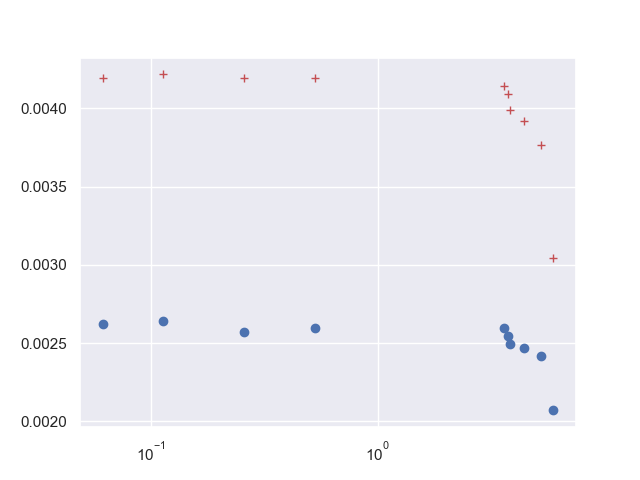

In [32]:
fig,ax = plt.subplots()
ax.plot(df_coord.loc[Res_Simulation_1984.index,'distance'], Res_Simulation_1984['Ca+2.tot'],'r+')
ax.plot(df_coord.loc[Res_Simulation_1984.index,'distance'], Res_Simulation_1985['Ca+2.tot'],'bo')
ax.set_xscale('log')

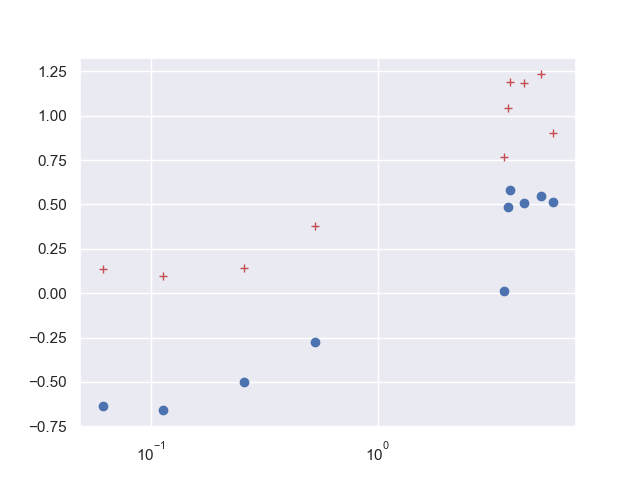

In [30]:
fig,ax = plt.subplots()
ax.plot(df_coord.loc[Res_Simulation_1984.index,'distance'], Res_Simulation_1984['Calcite[s].si'],'r+')
ax.plot(df_coord.loc[Res_Simulation_1984.index,'distance'], Res_Simulation_1985['Calcite[s].si'],'bo')
ax.set_xscale('log')

In [19]:
# Run a scenario for both datasets where we bring all samples to equilibrium and then we plot the amounts of calcite preciptitated along the stream
Res_Precip_1984 = pd.DataFrame(columns=OutVars1, index=df_data_1984.index)
OrchInput_Precip_1984 = pd.DataFrame(columns=InVars1, index=df_data_1984.index)


# set default watervolume and gasvolume
IN1[0][np.where(InVars1 == 'watervolume')] = 1.0 # per liter
IN1[0][np.where(InVars1 == 'gasvolume')] = 0.0 # no gas 
IN1[0][np.where(InVars1 == 'fixed_logact_CO2')] = -3.38 # not used for this calculation
IN1[0][np.where(InVars1 == 'deltaSIcalcite')] = 0.0 # not used for this calculation

# loop over available samplesCa_Range 
# we use a counter ii in order to store the results
for sample in df_data_1984.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -2, watervolume and gasvolume have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data_1984.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO2.set_and_calculate(IN1)

    OrchInput_Precip_1984.loc[sample] = IN1[0]    
    Res_Precip_1984.loc[sample] = OUT[0]

table_mdini = Res_Precip_1984[Res_List].to_markdown(floatfmt='.4e')
display(Markdown(table_mdini))

Res_Precip_1985 = pd.DataFrame(columns=OutVars1, index=df_data_1985.index)
OrchInput_Precip_1985 = pd.DataFrame(columns=InVars1, index=df_data_1985.index)

# loop over available samplesCa_Range 
# we use a counter ii in order to store the results
for sample in df_data_1985.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -2, watervolume and gasvolume have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data_1985.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO2.set_and_calculate(IN1)

    OrchInput_Precip_1985.loc[sample] = IN1[0]    
    Res_Precip_1985.loc[sample] = OUT[0]

table_mdini = Res_Precip_1985[Res_List].to_markdown(floatfmt='.4e')
display(Markdown(table_mdini))

| Sample   |         pH |          T |   HCO3-.tot |   Ca+2.tot |   HCO3-.con |   Ca+2.con |   HCO3-.diss |   Ca+2.diss |   CO2[g].con |   CO2[g].logact |   Calcite[s].si |   Calcite[s].tot |
|:---------|-----------:|-----------:|------------:|-----------:|------------:|-----------:|-------------:|------------:|-------------:|----------------:|----------------:|-----------------:|
| S-1      | 8.0092e+00 | 2.9745e+02 |  4.9657e-03 | 4.1168e-03 |  7.2105e-04 | 1.6594e-03 |   7.7582e-04 |  2.0629e-03 |   4.1687e-04 |     -3.3800e+00 |      1.3323e-15 |       2.0539e-03 |
| S-2      | 7.9948e+00 | 2.9785e+02 |  5.0786e-03 | 4.2166e-03 |  6.9473e-04 | 1.7746e-03 |   7.4908e-04 |  2.2156e-03 |   4.1687e-04 |     -3.3800e+00 |      4.4409e-16 |       2.0009e-03 |
| S-3      | 8.0098e+00 | 2.9775e+02 |  5.0947e-03 | 4.1916e-03 |  7.1961e-04 | 1.6538e-03 |   7.7467e-04 |  2.0628e-03 |   4.1687e-04 |     -3.3800e+00 |      8.8818e-16 |       2.1288e-03 |
| D-1      | 8.0078e+00 | 2.9745e+02 |  4.9980e-03 | 4.1916e-03 |  7.1888e-04 | 1.6702e-03 |   7.7373e-04 |  2.0753e-03 |   4.1687e-04 |     -3.3800e+00 |     -8.8818e-16 |       2.1163e-03 |
| D-3      | 8.0031e+00 | 2.9675e+02 |  5.0625e-03 | 4.1916e-03 |  7.1889e-04 | 1.7344e-03 |   7.7435e-04 |  2.1557e-03 |   4.1687e-04 |     -3.3800e+00 |      0.0000e+00 |       2.0359e-03 |
| F-1      | 8.0115e+00 | 2.9455e+02 |  5.0302e-03 | 4.1417e-03 |  7.5719e-04 | 1.7361e-03 |   8.1478e-04 |  2.1494e-03 |   4.1687e-04 |     -3.3800e+00 |      4.4409e-16 |       1.9923e-03 |
| F-2      | 8.0229e+00 | 2.9155e+02 |  4.2563e-03 | 3.7675e-03 |  8.1332e-04 | 1.7410e-03 |   8.7424e-04 |  2.1427e-03 |   4.1687e-04 |     -3.3800e+00 |      4.4409e-16 |       1.6248e-03 |
| F-3      | 8.0158e+00 | 2.9365e+02 |  5.0141e-03 | 4.0918e-03 |  7.7491e-04 | 1.7281e-03 |   8.3340e-04 |  2.1341e-03 |   4.1687e-04 |     -3.3800e+00 |      0.0000e+00 |       1.9577e-03 |
| F-4      | 8.0170e+00 | 2.9285e+02 |  4.4820e-03 | 3.9920e-03 |  7.8692e-04 | 1.7475e-03 |   8.4635e-04 |  2.1576e-03 |   4.1687e-04 |     -3.3800e+00 |     -1.3323e-15 |       1.8344e-03 |
| F-5      | 8.0182e+00 | 2.9275e+02 |  4.4014e-03 | 3.9172e-03 |  7.9001e-04 | 1.7386e-03 |   8.4953e-04 |  2.1436e-03 |   4.1687e-04 |     -3.3800e+00 |     -4.4409e-16 |       1.7736e-03 |
| F-6      | 8.0442e+00 | 2.8755e+02 |  3.3857e-03 | 3.0439e-03 |  9.0512e-04 | 1.6738e-03 |   9.7006e-04 |  2.0159e-03 |   4.1687e-04 |     -3.3800e+00 |     -4.4409e-16 |       1.0280e-03 |

| Sample   |         pH |          T |   HCO3-.tot |   Ca+2.tot |   HCO3-.con |   Ca+2.con |   HCO3-.diss |   Ca+2.diss |   CO2[g].con |   CO2[g].logact |   Calcite[s].si |   Calcite[s].tot |
|:---------|-----------:|-----------:|------------:|-----------:|------------:|-----------:|-------------:|------------:|-------------:|----------------:|----------------:|-----------------:|
| S-1      | 8.1001e+00 | 2.9315e+02 |  3.7727e-03 | 2.5449e-03 |  9.3098e-04 | 1.0945e-03 |   9.8950e-04 |  1.2678e-03 |   4.1687e-04 |     -3.3800e+00 |      0.0000e+00 |       1.2772e-03 |
| S-2      | 8.0852e+00 | 2.9315e+02 |  3.8694e-03 | 2.6447e-03 |  9.0080e-04 | 1.1798e-03 |   9.5881e-04 |  1.3730e-03 |   4.1687e-04 |     -3.3800e+00 |     -8.8818e-16 |       1.2717e-03 |
| S-3      | 8.0900e+00 | 2.9315e+02 |  3.8533e-03 | 2.6198e-03 |  9.1097e-04 | 1.1540e-03 |   9.6927e-04 |  1.3433e-03 |   4.1687e-04 |     -3.3800e+00 |     -4.4409e-16 |       1.2765e-03 |
| D-1      | 8.0935e+00 | 2.9265e+02 |  3.8210e-03 | 2.5699e-03 |  9.2522e-04 | 1.1456e-03 |   9.8414e-04 |  1.3320e-03 |   4.1687e-04 |     -3.3800e+00 |      4.4409e-16 |       1.2378e-03 |
| D-3      | 8.0931e+00 | 2.9015e+02 |  3.8210e-03 | 2.5948e-03 |  9.6052e-04 | 1.2054e-03 |   1.0219e-03 |  1.3966e-03 |   4.1687e-04 |     -3.3800e+00 |      4.4409e-16 |       1.1983e-03 |
| F-1      | 8.0927e+00 | 2.9015e+02 |  3.7888e-03 | 2.5948e-03 |  9.5998e-04 | 1.2091e-03 |   1.0215e-03 |  1.4025e-03 |   4.1687e-04 |     -3.3800e+00 |     -4.4409e-16 |       1.1923e-03 |
| F-2      | 8.0946e+00 | 2.8665e+02 |  3.3696e-03 | 2.4202e-03 |  1.0195e-03 | 1.2885e-03 |   1.0851e-03 |  1.4907e-03 |   4.1687e-04 |     -3.3800e+00 |      8.8818e-16 |       9.2948e-04 |
| F-3      | 8.0908e+00 | 2.8965e+02 |  3.7727e-03 | 2.5449e-03 |  9.6351e-04 | 1.2332e-03 |   1.0254e-03 |  1.4312e-03 |   4.1687e-04 |     -3.3800e+00 |     -4.4409e-16 |       1.1137e-03 |
| F-4      | 8.0977e+00 | 2.8615e+02 |  3.6114e-03 | 2.4950e-03 |  1.0347e-03 | 1.2810e-03 |   1.1009e-03 |  1.4798e-03 |   4.1687e-04 |     -3.3800e+00 |     -4.4409e-16 |       1.0152e-03 |
| F-5      | 8.0954e+00 | 2.8665e+02 |  3.5469e-03 | 2.4701e-03 |  1.0210e-03 | 1.2818e-03 |   1.0865e-03 |  1.4815e-03 |   4.1687e-04 |     -3.3800e+00 |     -8.8818e-16 |       9.8860e-04 |
| F-6      | 8.1151e+00 | 2.8415e+02 |  2.9504e-03 | 2.0709e-03 |  1.1089e-03 | 1.2161e-03 |   1.1777e-03 |  1.3857e-03 |   4.1687e-04 |     -3.3800e+00 |      4.4409e-16 |       6.8519e-04 |

Text(0, 0.5, 'Total Precipitated Calcite')

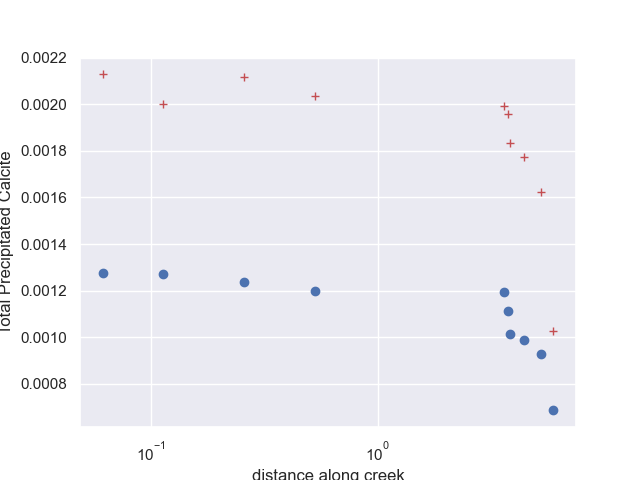

In [29]:
fig1,ax1 = plt.subplots()
ax1.plot(df_coord.loc[Res_Precip_1984.index,'distance'], Res_Precip_1984['Calcite[s].tot'],'r+')
ax1.plot(df_coord.loc[Res_Precip_1985.index,'distance'], Res_Precip_1985['Calcite[s].tot'],'bo')
ax1.set_xscale('log')
ax1.set_xlabel('distance along creek')
ax1.set_ylabel('Total Precipitated Calcite')

Text(0, 0.5, 'log(P_{CO_2})')

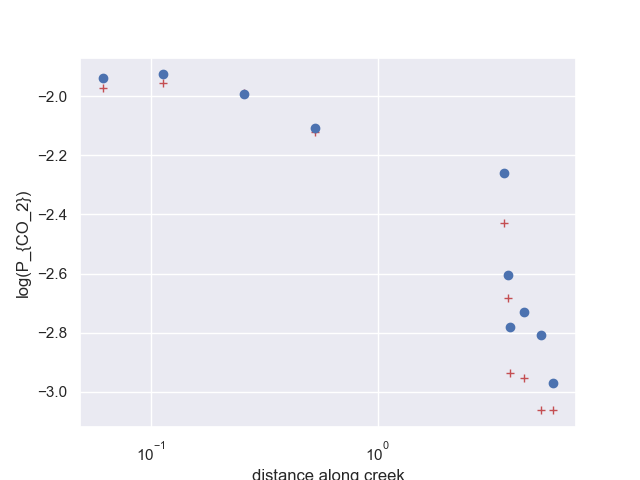

In [28]:
fig2,ax2 = plt.subplots()
ax2.plot(df_coord.loc[Res_Precip_1984.index,'distance'], Res_Simulation_1984['CO2[g].logact'],'r+')
ax2.plot(df_coord.loc[Res_Precip_1985.index,'distance'], Res_Simulation_1985['CO2[g].logact'],'bo')
ax2.set_xscale('log')
ax2.set_xlabel('distance along creek')
ax2.set_ylabel('log(P_{CO_2})')